## Prédiction du risque d’abandon scolaire

In [5]:
#Chargement des bibliothèques 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [6]:
#Chargement de notre jeu de données
df = pd.read_csv("data\student_dropout_dataset.csv")
df.head()

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1


<Axes: xlabel='dropout_risk'>

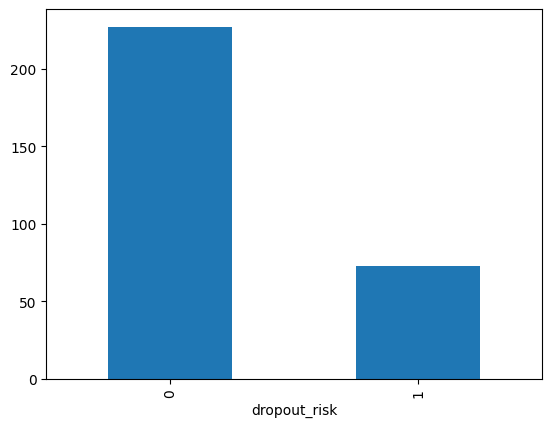

In [8]:
#Répartition des classes de la variable cible.

df['dropout_risk'].value_counts().plot(kind='bar')

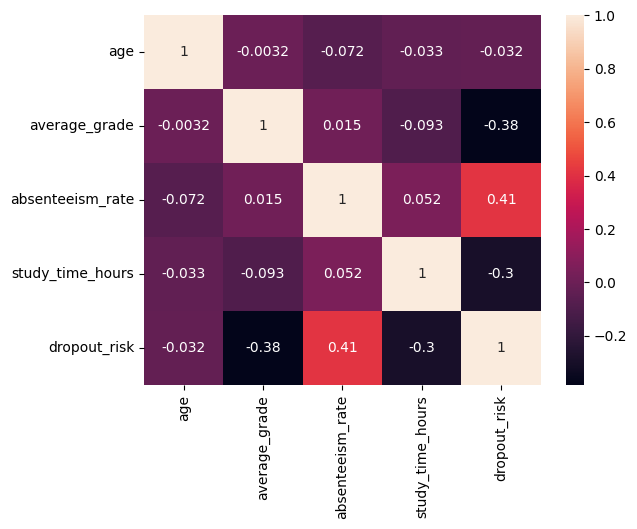

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Pre traitement des données

In [10]:
# Vérification des valeurs manquantes
print(df.isnull().sum())

age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64


In [11]:
#Encodage des variables catégorielles 
df = pd.get_dummies(df, drop_first=True)


In [12]:
#Normalisation (Z-score)

scaler = StandardScaler()
X = df.drop("dropout_risk", axis=1)
X_scaled = scaler.fit_transform(X)

## Analyse exploratoire 

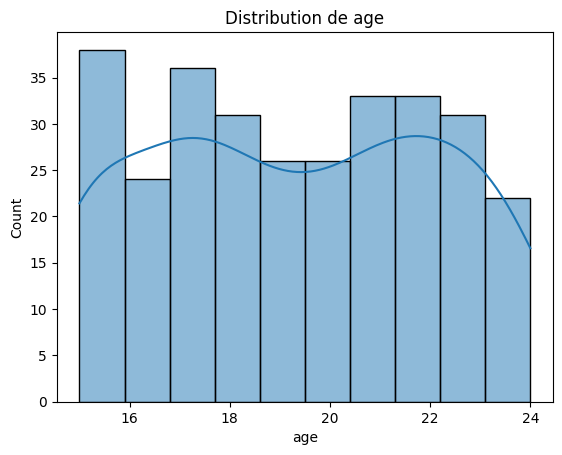

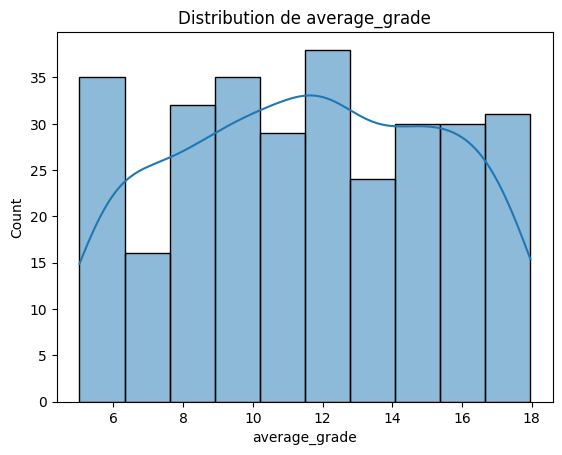

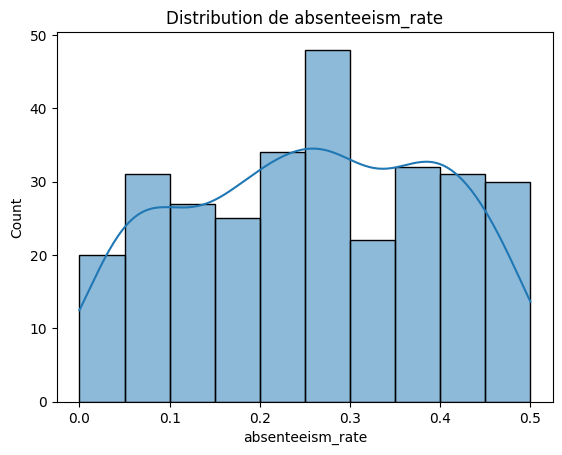

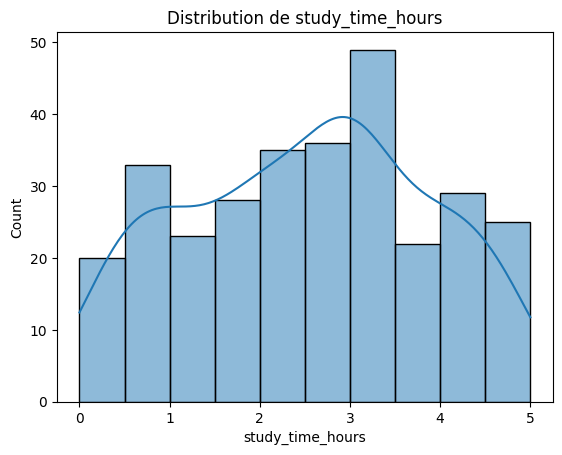

In [13]:
#Histogrammes (distribution des variables)
# Variables numériques
numerical_cols = ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours']

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

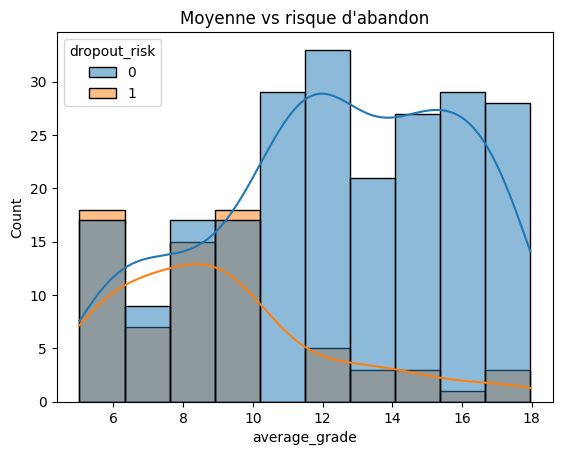

In [14]:
#Histogramme par rapport à la cible

sns.histplot(data=df, x="average_grade", hue="dropout_risk", kde=True)
plt.title("Moyenne vs risque d'abandon")
plt.show()

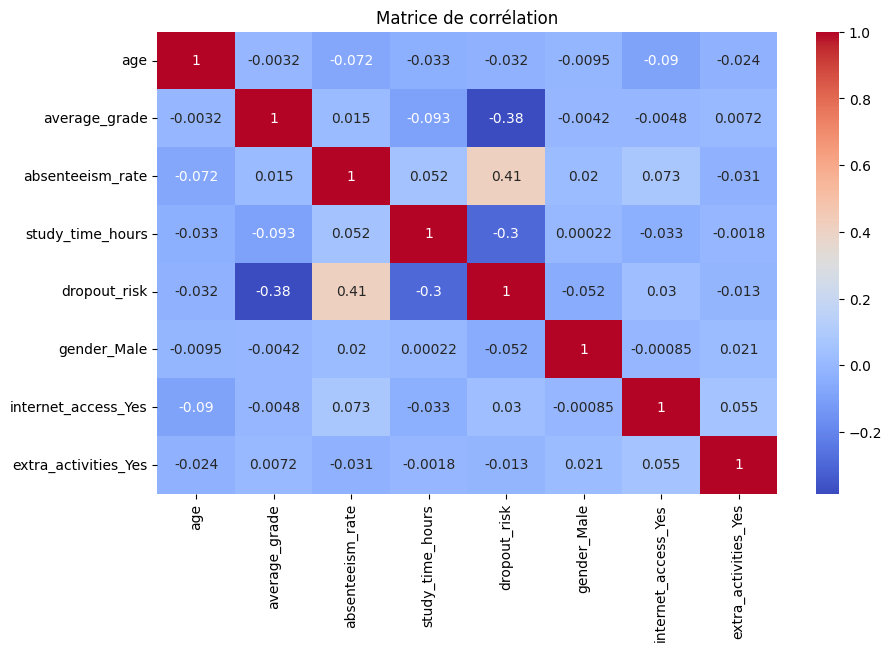

In [15]:
#Matrice de correlation

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [16]:
#Identification des variables importantes 

corr = df.corr(numeric_only=True)['dropout_risk'].sort_values(ascending=False)
print(corr)

dropout_risk            1.000000
absenteeism_rate        0.412653
internet_access_Yes     0.029846
extra_activities_Yes   -0.013273
age                    -0.032086
gender_Male            -0.051519
study_time_hours       -0.297416
average_grade          -0.384622
Name: dropout_risk, dtype: float64


<Axes: >

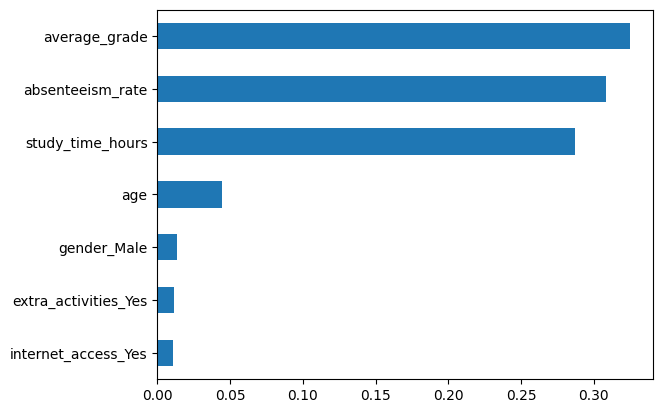

In [17]:
#Identification des variables importantes

X = df.drop("dropout_risk", axis=1)
Y = df["dropout_risk"]
# Modèle
from sklearn.ensemble import RandomForestClassifier 

model = RandomForestClassifier()
model.fit(X,Y)

# Importance des variables
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

## Future Engeneering

In [18]:
#Creation de nouvelles variables 

df['taux_presence'] = 1 - df['absenteeism_rate']

df['global_score'] = (
    df['average_grade'] * 0.5 +
    df['study_time_hours'] * 0.3 +
    df['taux_presence'] * 0.2
)

In [19]:
#verification de la pertinence des variables créées

corr = df.corr(numeric_only=True)['dropout_risk'].sort_values(ascending=False)
print(corr)

dropout_risk            1.000000
absenteeism_rate        0.412653
internet_access_Yes     0.029846
extra_activities_Yes   -0.013273
age                    -0.032086
gender_Male            -0.051519
study_time_hours       -0.297416
average_grade          -0.384622
taux_presence          -0.412653
global_score           -0.454017
Name: dropout_risk, dtype: float64


In [20]:
#Selection des variables importantes

'average_grade', 'absenteeism_rate','study_time_hours', 'global_score', 'taux_presence'


('average_grade',
 'absenteeism_rate',
 'study_time_hours',
 'global_score',
 'taux_presence')

## Modeliation 

In [21]:
#Séparation de notre jeu de données en test et apprentissage 

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

In [22]:
#Regression logistique 

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [23]:
#Forêt aleatoire 

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [24]:
#modèle_SVM
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [25]:
#Evaluation des modèles 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

results = []

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.866667   0.777778  0.538462  0.636364
1        Random Forest  0.983333   1.000000  0.923077  0.960000
2                  SVM  0.866667   0.727273  0.615385  0.666667


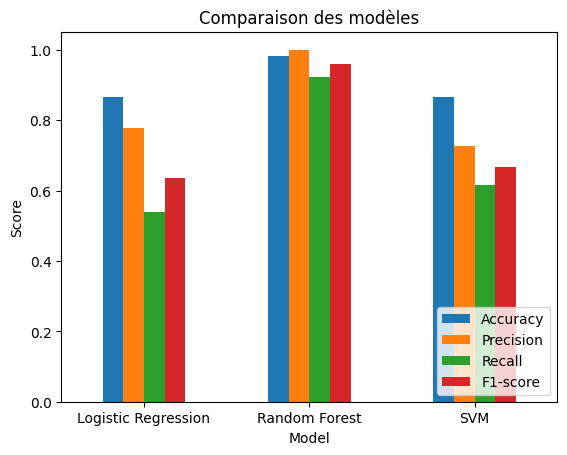

In [26]:
#Comparaison des modèles
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(kind="bar")

plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

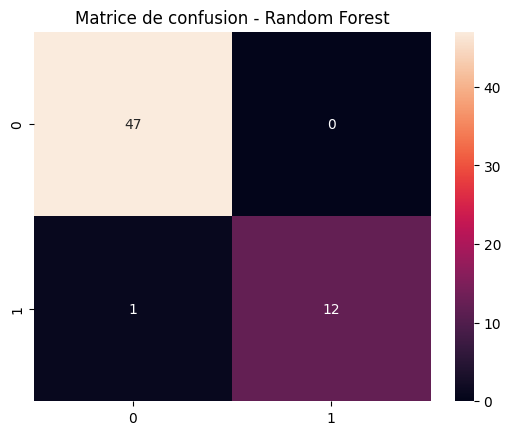

In [27]:
#Matrice de confusion Random forest

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)
plt.title("Matrice de confusion - Random Forest")
plt.show()

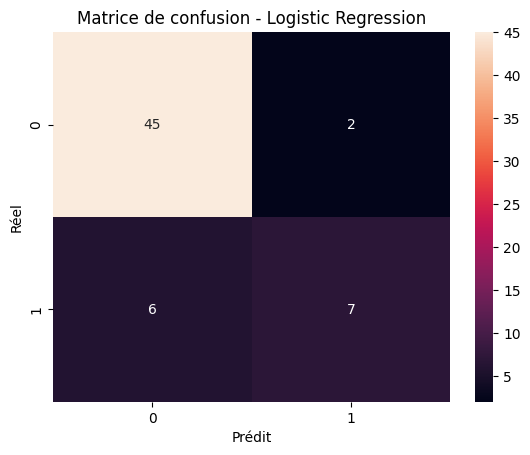

In [28]:
#Matrice de confusion modele_logistique 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Affichage
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

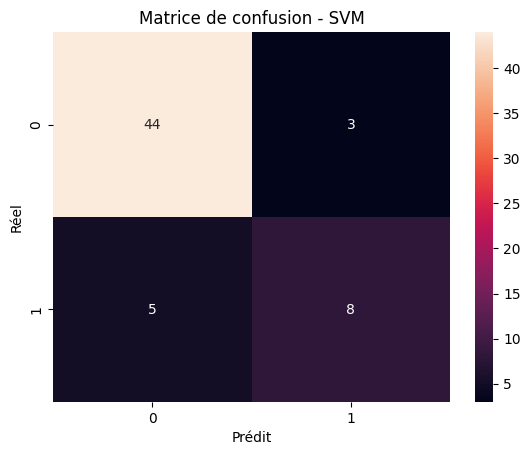

In [29]:
#Matrice_confusion modele_SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("Matrice de confusion - SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

## Optimisation 

In [30]:
# methode grid search sur Random forest

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)

Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [31]:
#Utilisation du meilleur modèle 

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)


In [32]:
#methode Random search sur random forest 

from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


In [33]:
#Optimisaton du SVM

from sklearn.svm import SVC

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(), param_svm, cv=5)

grid_svm.fit(X_train, y_train)

print(grid_svm.best_params_)

{'C': 0.1, 'kernel': 'linear'}


In [34]:
#Sauvegarde des differents modèles 
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))